# 复盘与总结

## 主流框架与工具对比

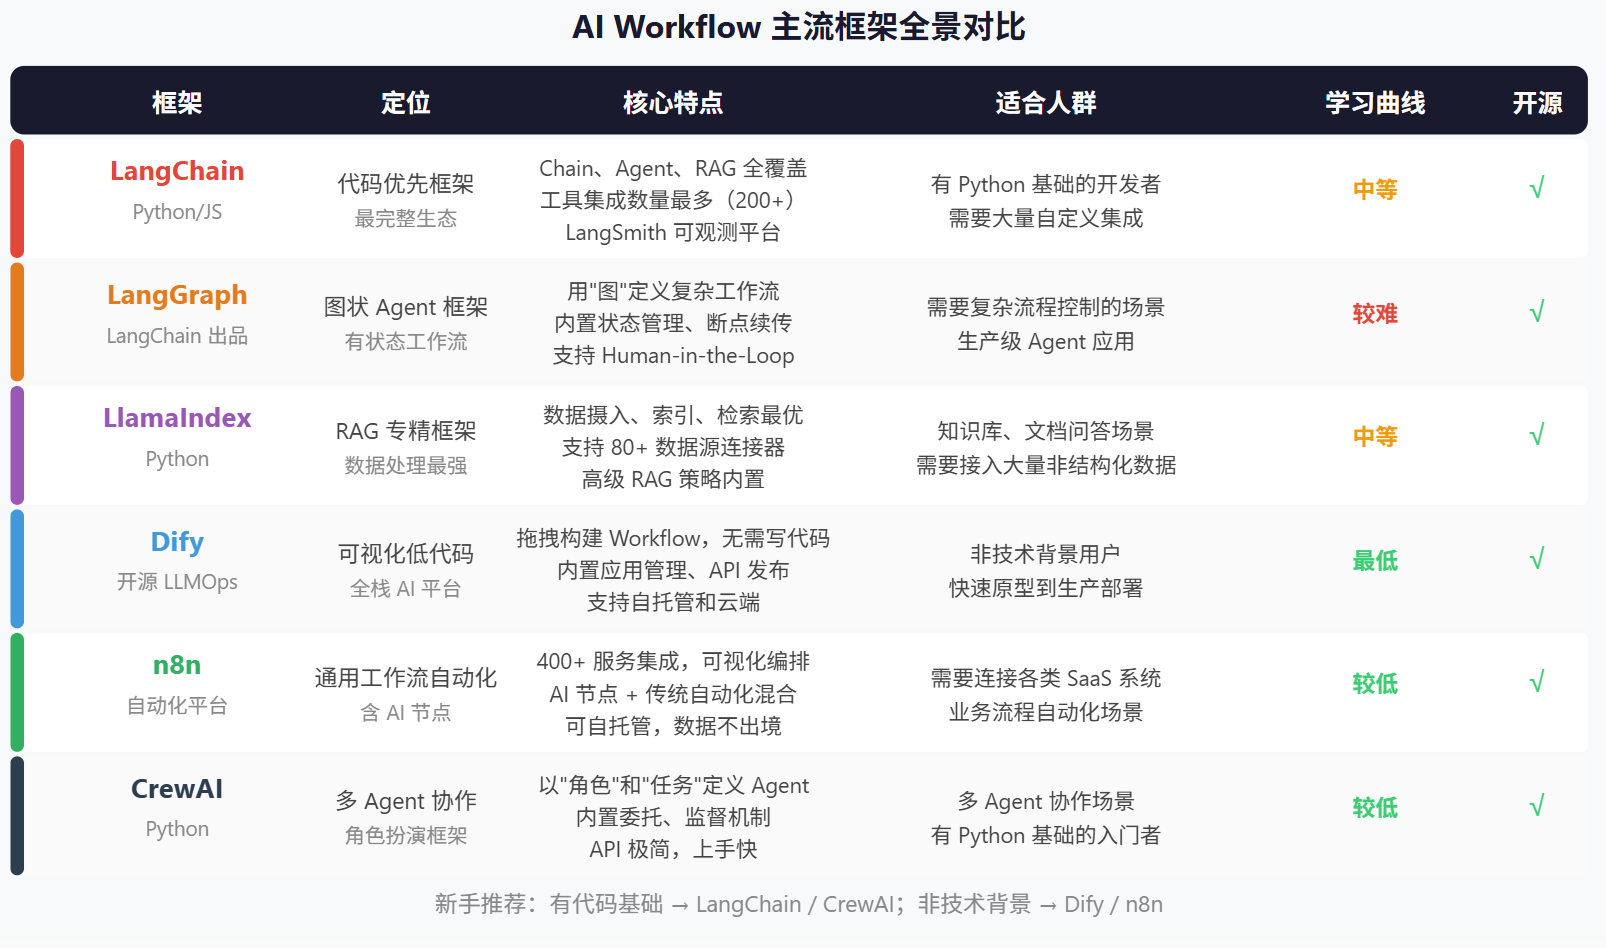

## 代码思路

In [ ]:
# 1. 先引入三+三个必须的库：
from langchain_openai import ChatOpenAI # 创建 LLM 对象
from langchain_core.prompts import ChatPromptTemplate # 创建 Prompt 模板 
from langchain_core.outputs import StrOutputParser # 规范输出

from langchain_core.runnables import RunnablePassthrough # 
import os # 使用os.dotenv获取.env中的DeepSeek_API_KEY参数
from dotenv import load_dotenv # 将.env参数加载进缓存以便os.dotenv获取


In [ ]:
# 2. 创建LLM对象
load_dotenv()          # 先获取.env中的参数
llm = ChatOpenAI(
    model="deepseek-flash",# 名字一定要对
    temperature=0.9,
    api_key=os.getenv("Deepseek_API_KEY"),# 调用数据
    base_url="https://api.deepseek.com" # 一般有api_key可以调用 
)

*ChatPromptTemplate是用来批量生成这种消息列表的模板工具。*
[
    SystemMessage("你是一个翻译助手"),
    HumanMessage("将以下英文翻译成中文：AI is..."),
]

In [ ]:
# 3. 创建三种作用的模板对象，并连接工作链
parser = StrOutputParser()
translate_prompt = ChatPromptTemplate(
    "请将以下英文翻译成中文，保持原意:\n\n{article}"
)  # 自动识别变量它会扫描字符串里的 {article}，知道"这个模板需要一个叫 article 的变量"
# {article} 是 Python str.format() 风格的占位符。LangChain 的模板引擎默认用它来标记"这里要填一个变量"。
translate_chain = translate_prompt | llm | parser

summarize_prompt = ChatPromptTemplate(
    "请将以下文章提炼三个要点，每点只用一句话：\n\n{translate}"
)
summarize_chain = summarize_prompt | llm | parser

title_prompt = ChatPromptTemplate(
    "请为以下文章生成一个简短的标题：\n\n{summary}"
)
title_chain = title_prompt | llm | parser

In [ ]:
# 4. 用"assign 模式"串起来
chain = (
    {"translate": translate_chain}
    | RunnablePassthrough.assign(summary=summarize_chain)
    | RunnablePassthrough.assign(title=title_chain)
)
# 原封不动保留输入字典的所有 key，在此基础上新增/覆盖 summary 这一个 key。


In [ ]:
# 5. article内容与结果打印
article = """
Artificial intelligence is transforming how we work and live.
From automating repetitive tasks to assisting in creative work,
AI tools are becoming indispensable in modern workflows...
"""
result = chain.invoke({"article": article})

# result={
# 'translate': '人工智能正在改变我们的工作和生活方式。从自动化重复性任务到辅助创造性工作，AI工具在现代工作流程中正变得不可或缺……', 
# 'summary': '您提供的文章似乎不完整（以省略号结尾）。基于现有内容，我提炼出以下三个要点：\n\n
#   1. 人工智能正在深刻改变人们的工作和生活方式。\n2. AI 的应用范围广泛，从自动化重复性任务到辅助创造性工作。\n
#   3. AI 工具正成为现代工作流程中不可或缺的组成部分。\n\n如果您能提供完整文章，我可以给出更全面准确的要点提炼。', 
# 'title': '**《AI：重塑现代工作与生活的核心力量》**\n\n
#   备选标题：\n- 《人工智能：从效率工具到工作伙伴》\n- 《AI时代的到来：工作方式的深刻变革》\n- 《不可或缺的AI：现代工作流程新标配》\n\n
# 如果您能提供完整原文，我可以给出更贴合文章主旨的标题。'
# }